In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    AutoModel
)
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
print("=" * 50)
print(f"🔍 GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)}")
print("=" * 50)

🔍 GPU Available: True
🖥️  GPU: Tesla T4


In [ ]:
# Load Twitter Financial News Sentiment dataset
dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")
print(f"✅ Dataset loaded: zeroshot/twitter-financial-news-sentiment")
print(f"📊 Train samples: {len(dataset['train'])}")
print(f"📊 Validation samples: {len(dataset['validation'])}")

# View sample data
print("\n🔍 Sample data:")
df_sample = pd.DataFrame(dataset['train'][:5])
print(df_sample.to_string())

# Label mapping
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
print(f"\n🏷️  Labels: {label_names}")

# Check label distribution
labels = dataset['train']['label']
unique, counts = np.unique(labels, return_counts=True)
print(f"\n📈 Label Distribution (Train):")
for u, c in zip(unique, counts):
    print(f"   {label_names[u]}: {c} samples ({c/len(labels)*100:.1f}%)")

# Use existing train/validation split
train_dataset = dataset['train']
val_dataset = dataset['validation']
print(f"\n✂️  Dataset split:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Validation: {len(val_dataset)} samples")

✅ Dataset loaded: zeroshot/twitter-financial-news-sentiment
📊 Train samples: 9543
📊 Validation samples: 2388

🔍 Sample data:
                                                                                                     text  label
0                           $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT      0
1  $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3      0
2          $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb      0
3                                             $ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N      0
4                                 $FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB      0

🏷️  Labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

📈 Label Distribution (Train):
   Negative: 1442 samples (15.1%)
   Neutral: 1923 samples (20.2%)
   Positive: 6178 samples (64.7%)

✂️  Da

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

# Tokenizer setup
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
...

Ellipsis

In [ ]:
# Tokenizer setup
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenization function
def preprocess_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=True,
        max_length=128
    )

# Apply tokenization
print("🔤 Tokenizing dataset...")
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

# Remove original text column to keep only model inputs
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])

# Rename label column for Trainer compatibility
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")

# DO NOT set_format - let Trainer handle it automatically
# (avoids torchvision/datasets compatibility bug)

print(f"✅ Tokenization complete!")
print(f"   Columns: {tokenized_train.column_names}")
print(f"   Sample input_ids length: {len(tokenized_train[0]['input_ids'])}")

# Display training configuration
print("\n" + "-" * 50)
print("⚙️  TRAINING CONFIGURATION:")
print("-" * 50)
print("   • Batch Size: 16")
print("   • Learning Rate: 2e-5")
print("   • Epochs: 3")
print("   • Weight Decay: 0.01")
print("   • Evaluation Strategy: Per Epoch")
print("   • Save Strategy: Per Epoch")
print("   • Load Best Model: Yes (based on F1)")
print("-" * 50)

🔤 Tokenizing dataset...
✅ Tokenization complete!
   Columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
   Sample input_ids length: 82

--------------------------------------------------
⚙️  TRAINING CONFIGURATION:
--------------------------------------------------
   • Batch Size: 16
   • Learning Rate: 2e-5
   • Epochs: 3
   • Weight Decay: 0.01
   • Evaluation Strategy: Per Epoch
   • Save Strategy: Per Epoch
   • Load Best Model: Yes (based on F1)
--------------------------------------------------


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir="./finetuned-financial-distilbert",
    eval_strategy="epoch",           # Changed from 'evaluation_strategy'
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",  # Disable wandb for Colab simplicity
)

# Metric computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Load model with 3 output labels
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=label_names,
    label2id={v: k for k, v in label_names.items()}
)

print(f"✅ Model loaded: {MODEL_NAME}")
print(f"   Number of labels: 3")
print(f"   Output: {model.classifier}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
   Number of labels: 3
   Output: Linear(in_features=768, out_features=3, bias=True)


In [ ]:
from transformers import DataCollatorWithPadding

# Initialize data collator with padding (handles variable-length sequences)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,  # <-- ADD THIS
    compute_metrics=compute_metrics,
)

print("🚀 Starting training...\n")
trainer.train()
print("\n✅ Training complete!")

# Save the fine-tuned model
trainer.save_model("./finetuned-financial-distilbert-final")
print("💾 Model saved to: ./finetuned-financial-distilbert-final")

🚀 Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.441630,0.388161,0.853434,0.856061
2,0.225930,0.337949,0.880653,0.880481
3,0.182017,0.378333,0.878978,0.878996


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model saved to: ./finetuned-financial-distilbert-final


In [ ]:
# Get predictions on validation set
print("🔮 Running predictions on validation set...")
predictions = trainer.predict(tokenized_val)
logits = predictions.predictions
preds = np.argmax(logits, axis=-1)
true_labels = predictions.label_ids

# Calculate metrics
acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average="weighted")
f1_per_class = f1_score(true_labels, preds, average=None)

print(f"\n📊 OVERALL METRICS:")
print(f"   Accuracy: {acc:.4f}")
print(f"   Weighted F1-Score: {f1:.4f}")

print(f"\n📊 PER-CLASS F1-SCORE:")
for i, name in label_names.items():
    print(f"   {name}: {f1_per_class[i]:.4f}")

print(f"\n📋 CLASSIFICATION REPORT:")
print(classification_report(true_labels, preds, target_names=list(label_names.values())))

🔮 Running predictions on validation set...



📊 OVERALL METRICS:
   Accuracy: 0.8807
   Weighted F1-Score: 0.8805

📊 PER-CLASS F1-SCORE:
   Negative: 0.7826
   Neutral: 0.8219
   Positive: 0.9199

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.76      0.80      0.78       347
     Neutral       0.85      0.79      0.82       475
    Positive       0.92      0.92      0.92      1566

    accuracy                           0.88      2388
   macro avg       0.84      0.84      0.84      2388
weighted avg       0.88      0.88      0.88      2388



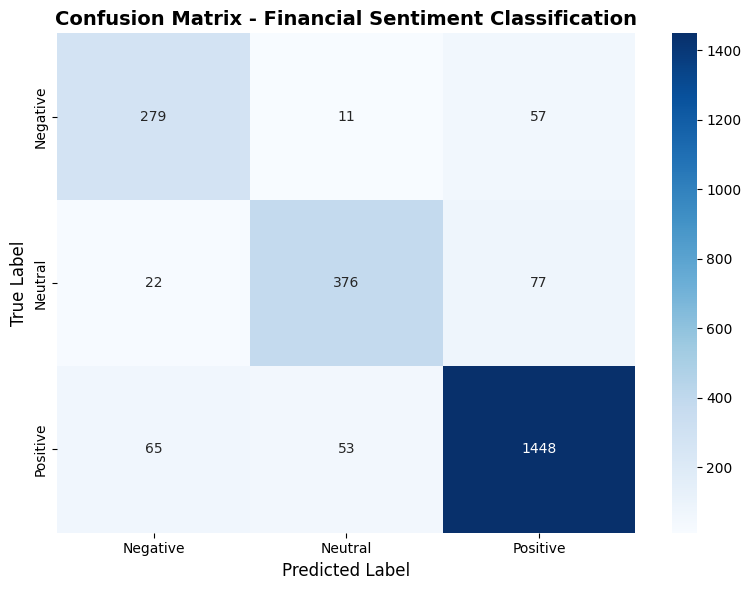

📸 Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(true_labels, preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(label_names.values()),
    yticklabels=list(label_names.values())
)
plt.title("Confusion Matrix - Financial Sentiment Classification", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("📸 Confusion matrix saved as 'confusion_matrix.png'")

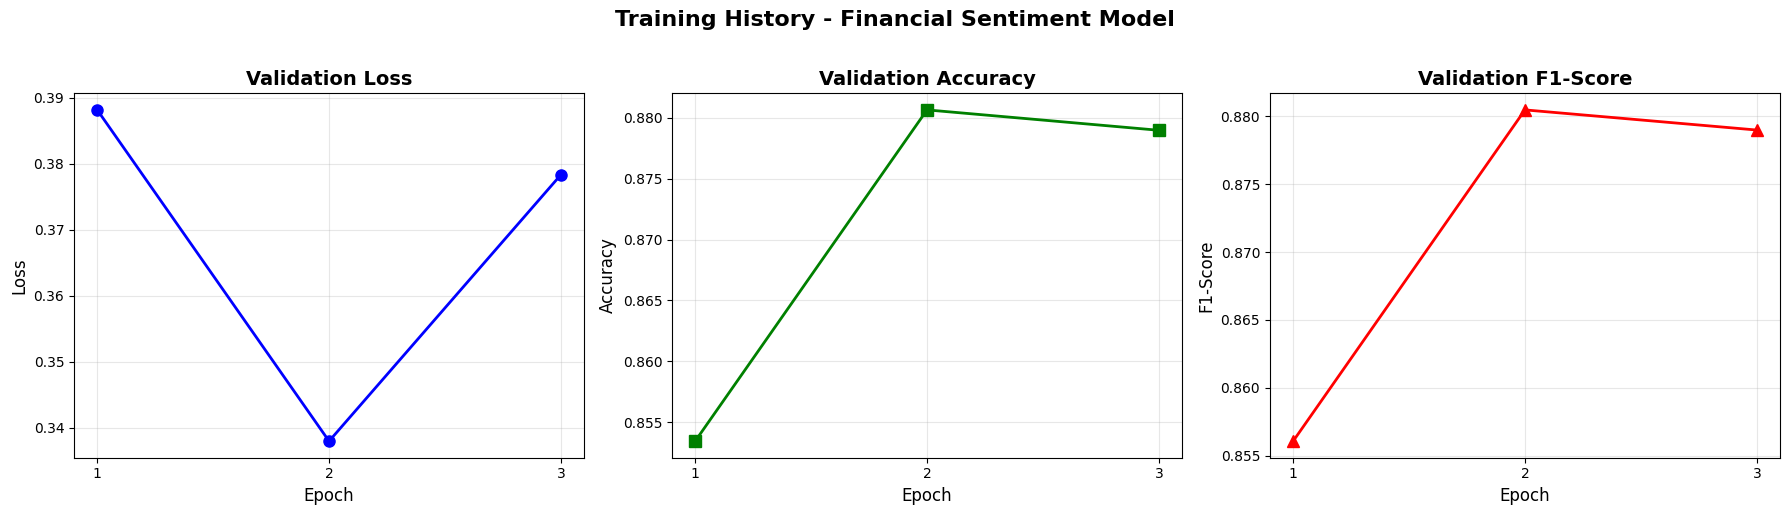

📸 Training history saved as 'training_history.png'


In [ ]:
# Training History Visualization
history = trainer.state.log_history
eval_loss = [h['eval_loss'] for h in history if 'eval_loss' in h]
eval_acc = [h['eval_accuracy'] for h in history if 'eval_accuracy' in h]
eval_f1 = [h['eval_f1'] for h in history if 'eval_f1' in h]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(range(1, len(eval_loss)+1), eval_loss, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, len(eval_loss)+1))

# Accuracy plot
axes[1].plot(range(1, len(eval_acc)+1), eval_acc, 'g-s', linewidth=2, markersize=8)
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, len(eval_acc)+1))

# F1 Score plot
axes[2].plot(range(1, len(eval_f1)+1), eval_f1, 'r-^', linewidth=2, markersize=8)
axes[2].set_title('Validation F1-Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(range(1, len(eval_f1)+1))

plt.suptitle('Training History - Financial Sentiment Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("📸 Training history saved as 'training_history.png'")

In [ ]:
# Load the fine-tuned model for extracting embeddings
embedding_model = AutoModel.from_pretrained("./finetuned-financial-distilbert-final")
embedding_model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedding_model.to(device)

print(f"✅ Embedding model loaded on {device.upper()}")

# 25 Financial domain words for visualization
financial_words = [
    # Positive sentiment words
    "profit", "growth", "gain", "success", "boom", "surge", "rise", "strong",
    "bullish", "optimistic", "recovery", "expansion",
    # Negative sentiment words
    "loss", "decline", "crash", "crisis", "recession", "bankruptcy", "fall",
    "weak", "bearish", "pessimistic", "debt", "risk",
    # Neutral/General financial terms
    "market", "stock", "investment", "revenue", "economy"
]

print(f"📊 Visualizing {len(financial_words)} financial words")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ./finetuned-financial-distilbert-final
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.bias   | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded on CUDA
📊 Visualizing 29 financial words


In [ ]:
# Function to extract word embedding (using [CLS] token)
def get_word_embedding(word, model, tokenizer):
    """Extract embedding for a single word using [CLS] token representation."""
    inputs = tokenizer(word, return_tensors="pt", padding=True, truncation=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        # Use [CLS] token embedding (first token) as representation
        embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

    return embedding[0]

# Collect embeddings for all words
embeddings = []
valid_words = []

print("🔍 Extracting embeddings...")
for word in financial_words:
    try:
        emb = get_word_embedding(word, embedding_model, tokenizer)
        embeddings.append(emb)
        valid_words.append(word)
        print(f"   ✓ {word}")
    except Exception as e:
        print(f"   ✗ {word}: {e}")

embeddings = np.array(embeddings)
print(f"\n✅ Successfully extracted {len(valid_words)} embeddings")
print(f"📐 Embedding dimension: {embeddings.shape[1]}")

🔍 Extracting embeddings...
   ✓ profit
   ✓ growth
   ✓ gain
   ✓ success
   ✓ boom
   ✓ surge
   ✓ rise
   ✓ strong
   ✓ bullish
   ✓ optimistic
   ✓ recovery
   ✓ expansion
   ✓ loss
   ✓ decline
   ✓ crash
   ✓ crisis
   ✓ recession
   ✓ bankruptcy
   ✓ fall
   ✓ weak
   ✓ bearish
   ✓ pessimistic
   ✓ debt
   ✓ risk
   ✓ market
   ✓ stock
   ✓ investment
   ✓ revenue
   ✓ economy

✅ Successfully extracted 29 embeddings
📐 Embedding dimension: 768


In [ ]:
# Apply PCA to reduce from 768D to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Calculate explained variance
explained_var = pca.explained_variance_ratio_
print(f"\n📊 PCA EXPLAINED VARIANCE:")
print(f"   PC1: {explained_var[0]:.4f} ({explained_var[0]*100:.2f}%)")
print(f"   PC2: {explained_var[1]:.4f} ({explained_var[1]*100:.2f}%)")
print(f"   Total: {sum(explained_var):.4f} ({sum(explained_var)*100:.2f}%)")

# Define sentiment categories for coloring
positive_words = ["profit", "growth", "gain", "success", "boom", "surge", "rise",
                  "strong", "bullish", "optimistic", "recovery", "expansion"]
negative_words = ["loss", "decline", "crash", "crisis", "recession", "bankruptcy",
                  "fall", "weak", "bearish", "pessimistic", "debt", "risk"]
neutral_words = ["market", "stock", "investment", "revenue", "economy"]

def get_sentiment_color(word):
    if word in positive_words:
        return '#2ecc71'  # Green - Positive
    elif word in negative_words:
        return '#e74c3c'  # Red - Negative
    else:
        return '#3498db'  # Blue - Neutral

colors = [get_sentiment_color(w) for w in valid_words]


📊 PCA EXPLAINED VARIANCE:
   PC1: 0.3397 (33.97%)
   PC2: 0.1556 (15.56%)
   Total: 0.4953 (49.53%)


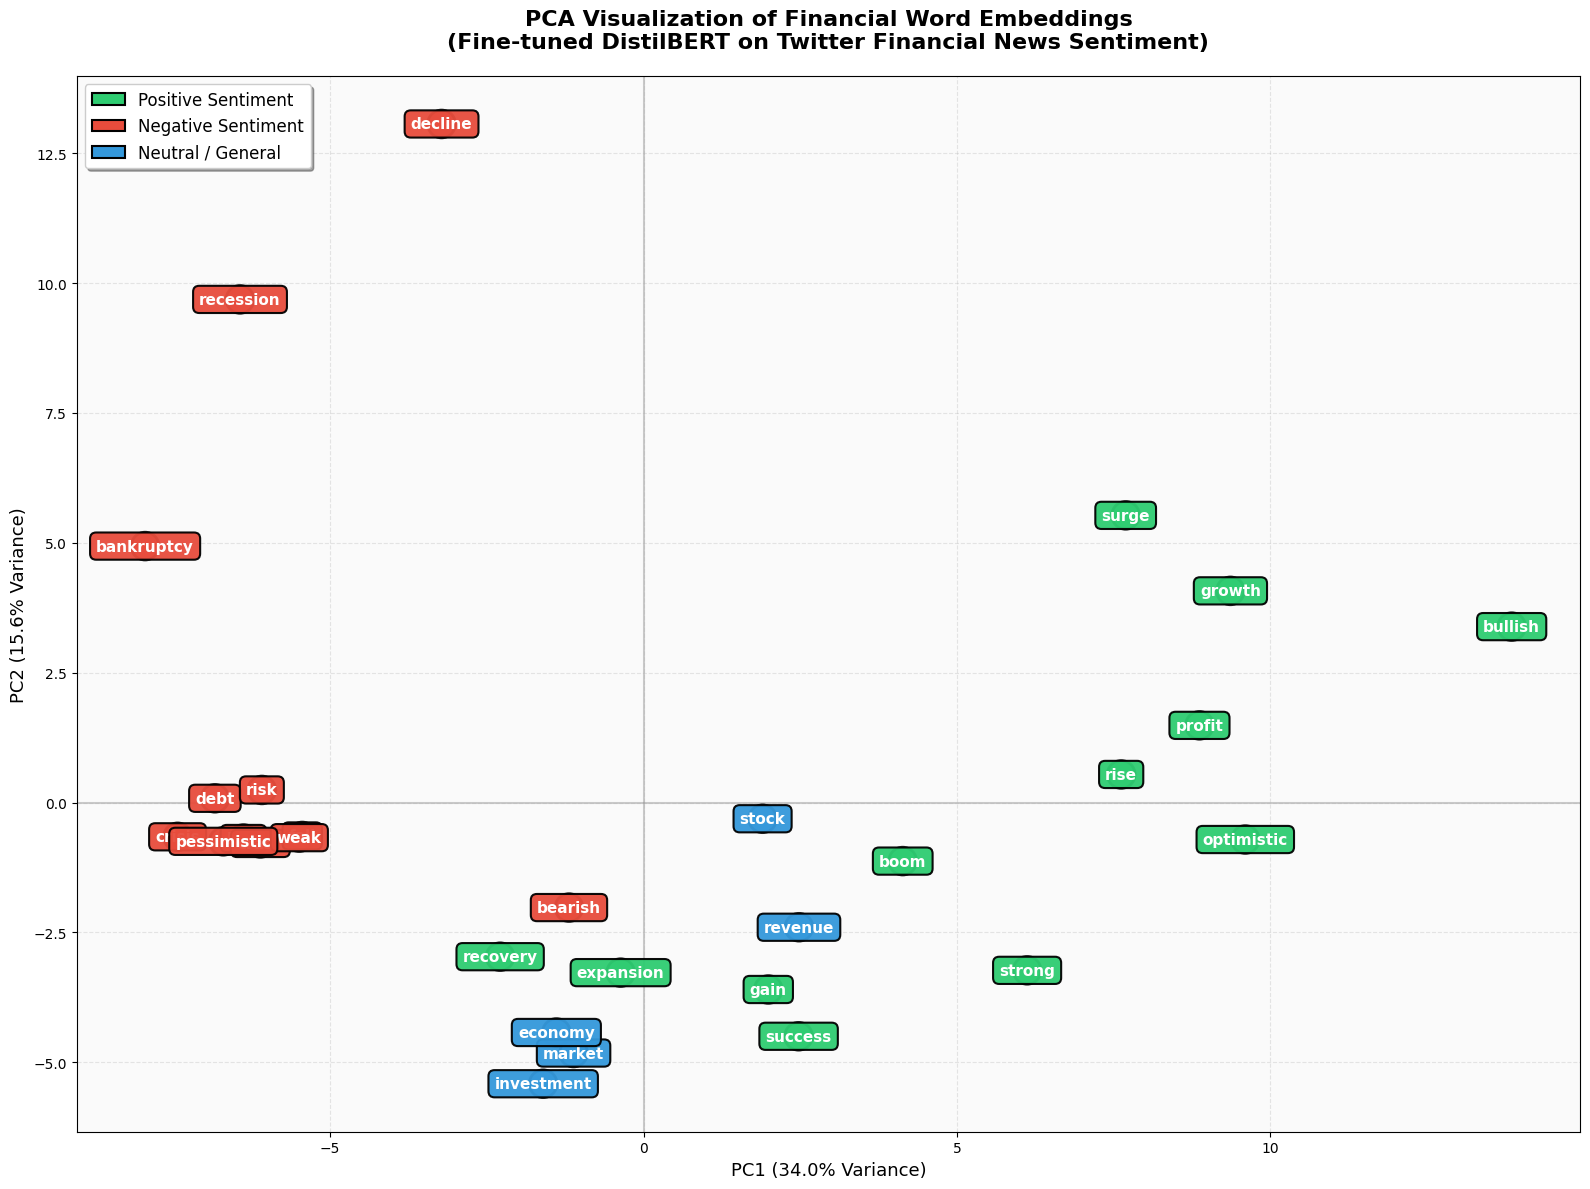


PCA visualization saved as 'pca_word_embeddings.png'


In [ ]:
# Create the PCA Visualization Plot
plt.figure(figsize=(16, 12))

# Scatter plot
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=colors,
    s=400,
    alpha=0.8,
    edgecolors='black',
    linewidth=2,
    zorder=3
)

# Add word labels with background boxes
for i, word in enumerate(valid_words):
    plt.annotate(
        word,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='center',
        color='white',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor=colors[i],
            alpha=0.95,
            edgecolor='black',
            linewidth=1.5
        ),
        zorder=4
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Positive Sentiment', linewidth=1.5),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Negative Sentiment', linewidth=1.5),
    Patch(facecolor='#3498db', edgecolor='black', label='Neutral / General', linewidth=1.5)
]
plt.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=12,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.title(
    'PCA Visualization of Financial Word Embeddings\n(Fine-tuned DistilBERT on Twitter Financial News Sentiment)',
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% Variance)', fontsize=13)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% Variance)', fontsize=13)

# Grid and axes
plt.grid(True, alpha=0.3, linestyle='--', zorder=1)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.4, zorder=1)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.4, zorder=1)

# Add subtle background color
plt.gca().set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig("pca_word_embeddings.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nPCA visualization saved as 'pca_word_embeddings.png'")

In [ ]:
test_sentences = [
    "The company reported record profits this quarter.",
    "Stock prices plummeted after the accounting scandal.",
    "The merger will be completed next month as planned.",
    "Investors are optimistic about the new product launch.",
    "The firm filed for bankruptcy protection yesterday.",
    "Revenue remained stable compared to last year.",
    "The market showed strong bullish signals today."
]

print("\n🔮 Testing model on sample sentences:\n")
print("-" * 70)

for sentence in test_sentences:
    # Tokenize and predict
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()
        probs = torch.softmax(outputs.logits, dim=-1)[0]

    confidence = probs[pred].item()
    sentiment = label_names[pred]

    # Emoji for sentiment
    emoji = "🟢" if sentiment == "Positive" else "🔴" if sentiment == "Negative" else "⚪"

    print(f"{emoji} Text: {sentence}")
    print(f"   Prediction: {sentiment} (confidence: {confidence:.4f})")
    print("-" * 70)


🔮 Testing model on sample sentences:

----------------------------------------------------------------------
⚪ Text: The company reported record profits this quarter.
   Prediction: Neutral (confidence: 0.8984)
----------------------------------------------------------------------
🔴 Text: Stock prices plummeted after the accounting scandal.
   Prediction: Negative (confidence: 0.9508)
----------------------------------------------------------------------
🟢 Text: The merger will be completed next month as planned.
   Prediction: Positive (confidence: 0.9838)
----------------------------------------------------------------------
⚪ Text: Investors are optimistic about the new product launch.
   Prediction: Neutral (confidence: 0.9143)
----------------------------------------------------------------------
🔴 Text: The firm filed for bankruptcy protection yesterday.
   Prediction: Negative (confidence: 0.6840)
----------------------------------------------------------------------
⚪ Text: Re

In [ ]:
summary_data = {
    "Component": [
        "Task",
        "Domain",
        "LLM Used",
        "Dataset",
        "Dataset Size",
        "Train/Val Split",
        "Batch Size",
        "Learning Rate",
        "Epochs",
        "Final Accuracy",
        "Final Weighted F1",
        "Words Visualized (PCA)"
    ],
    "Details": [
        "Text Classification (Financial Sentiment)",
        "Finance / Financial Markets",
        "distilbert-base-uncased (~66M params)",
        "zeroshot/twitter-financial-news-sentiment",
        f"{len(train_dataset) + len(val_dataset)} sentences",  # 11931 sentences
        "Built-in split (9543 / 2388)",
        "16",
        "2e-5",
        "3",
        f"{acc:.4f}",
        f"{f1:.4f}",
        f"{len(valid_words)} words"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))


             Component                                   Details
                  Task Text Classification (Financial Sentiment)
                Domain               Finance / Financial Markets
              LLM Used     distilbert-base-uncased (~66M params)
               Dataset zeroshot/twitter-financial-news-sentiment
          Dataset Size                           11931 sentences
       Train/Val Split              Built-in split (9543 / 2388)
            Batch Size                                        16
         Learning Rate                                      2e-5
                Epochs                                         3
        Final Accuracy                                    0.8807
     Final Weighted F1                                    0.8805
Words Visualized (PCA)                                  29 words
